# Supplementary: Recording stability over time

**Purpose:** Show that AP waveform parameter variance does not systematically increase over recording time, rebutting the patch-degradation / dying-neuron concern.

- **Panel B** — Rolling IQR: mean ± SEM across cells per time bin
- **Panel C** — Temporal slope distribution: linear regression of |Δ| vs time per (cell × feature)
- **Panel D** — Firing rate stability over time

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
import importlib
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    plot_temporal_rolling_iqr,
    plot_rolling_iqr_legend,
    plot_temporal_slopes,
    plot_firing_rate_stability,
)
import config

CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'

## Panel B — Rolling IQR (mean ± SEM across cells)

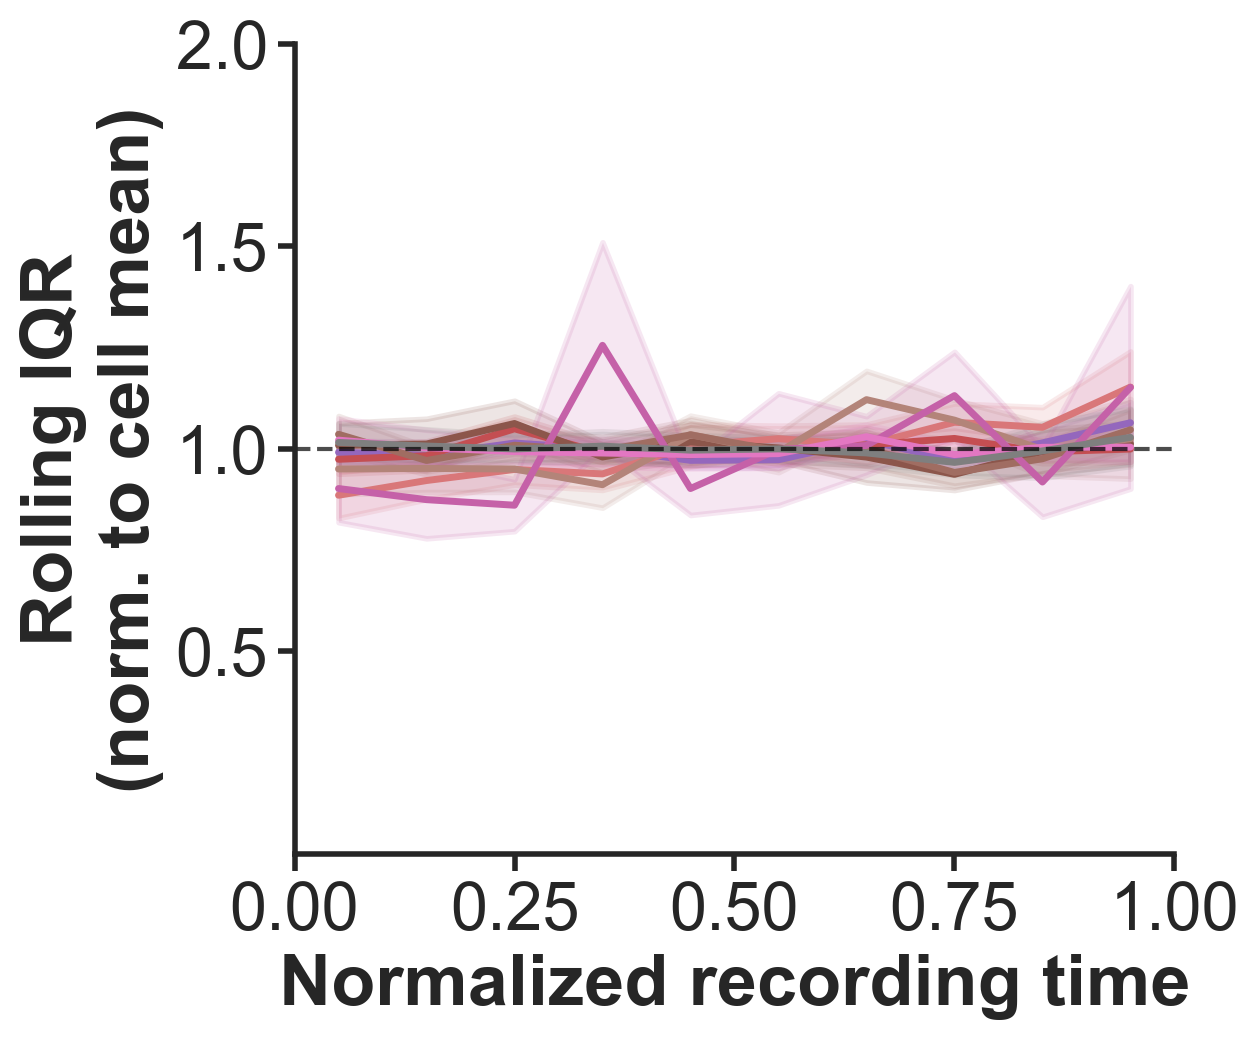

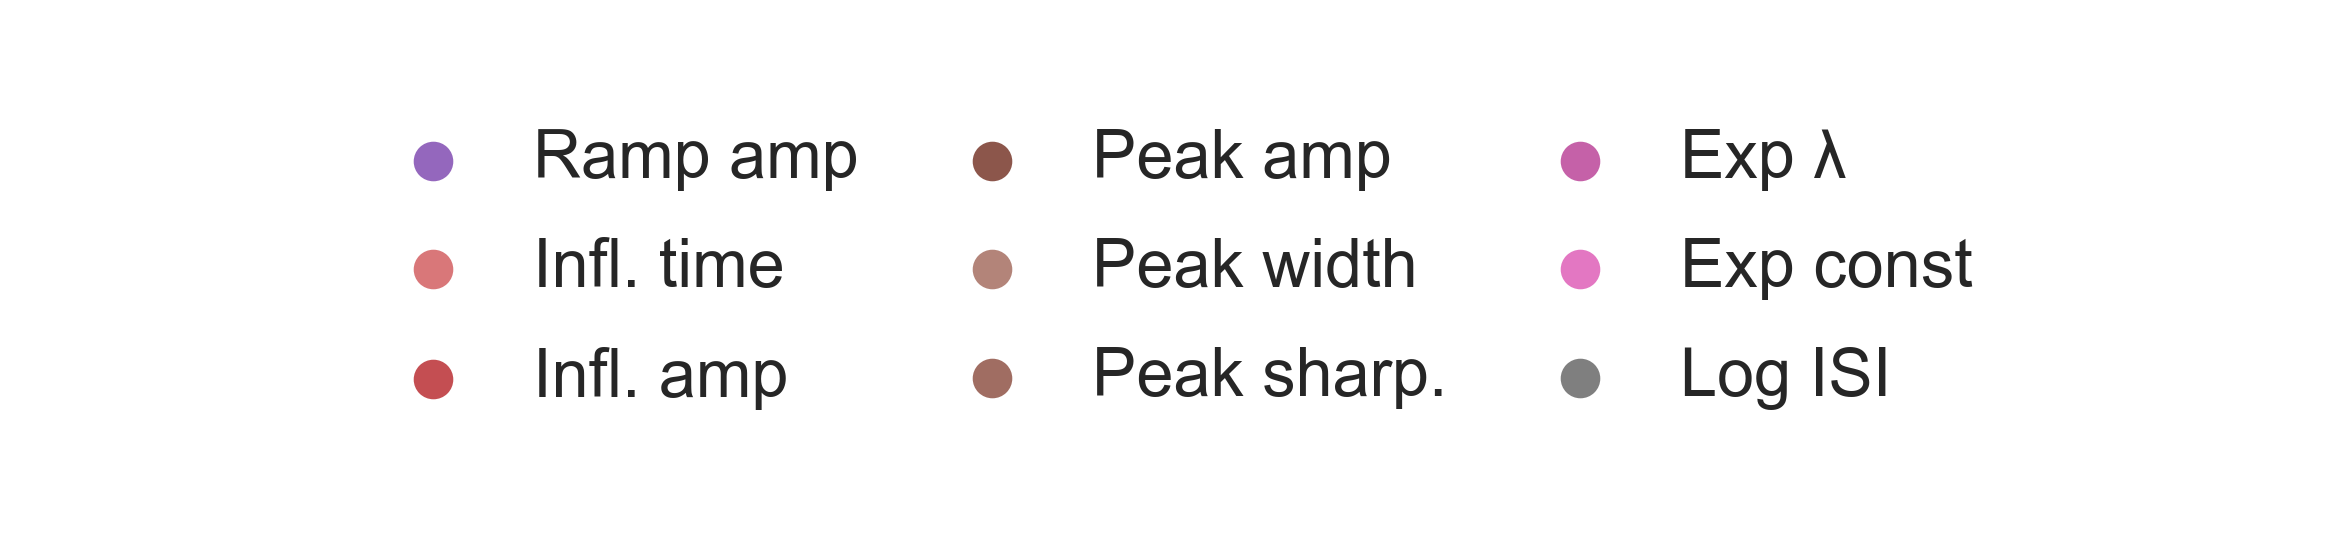

In [6]:
plot_temporal_rolling_iqr(CLUSTER_PKL_DIR)
plot_rolling_iqr_legend()

## Panel C — Temporal slope distribution

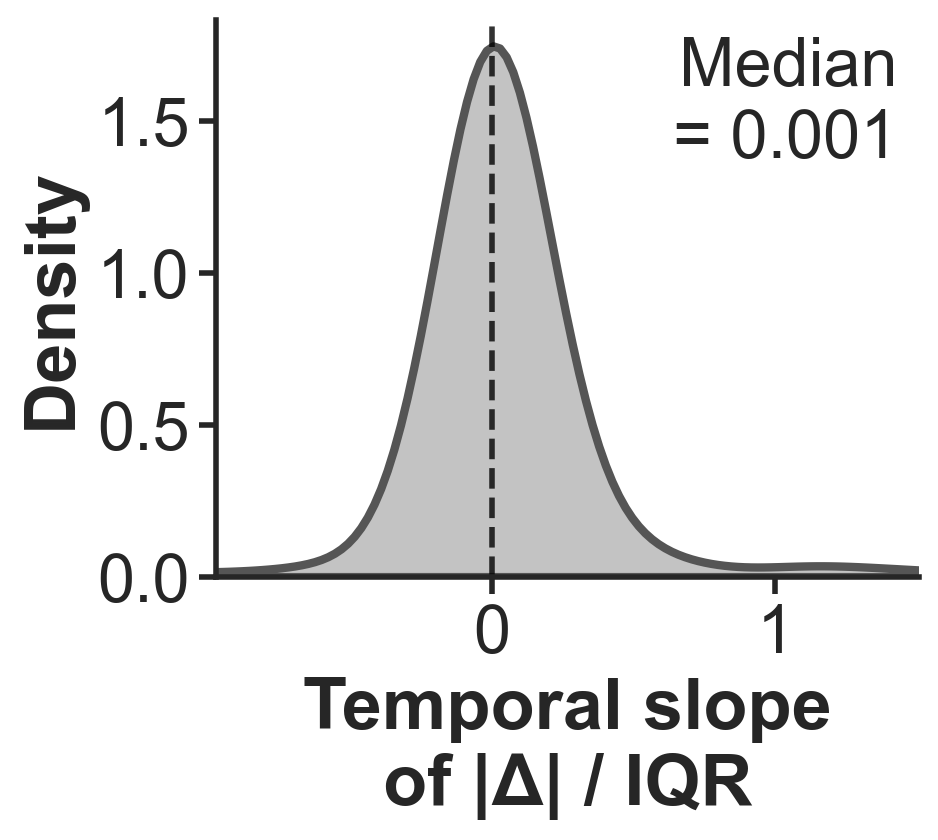

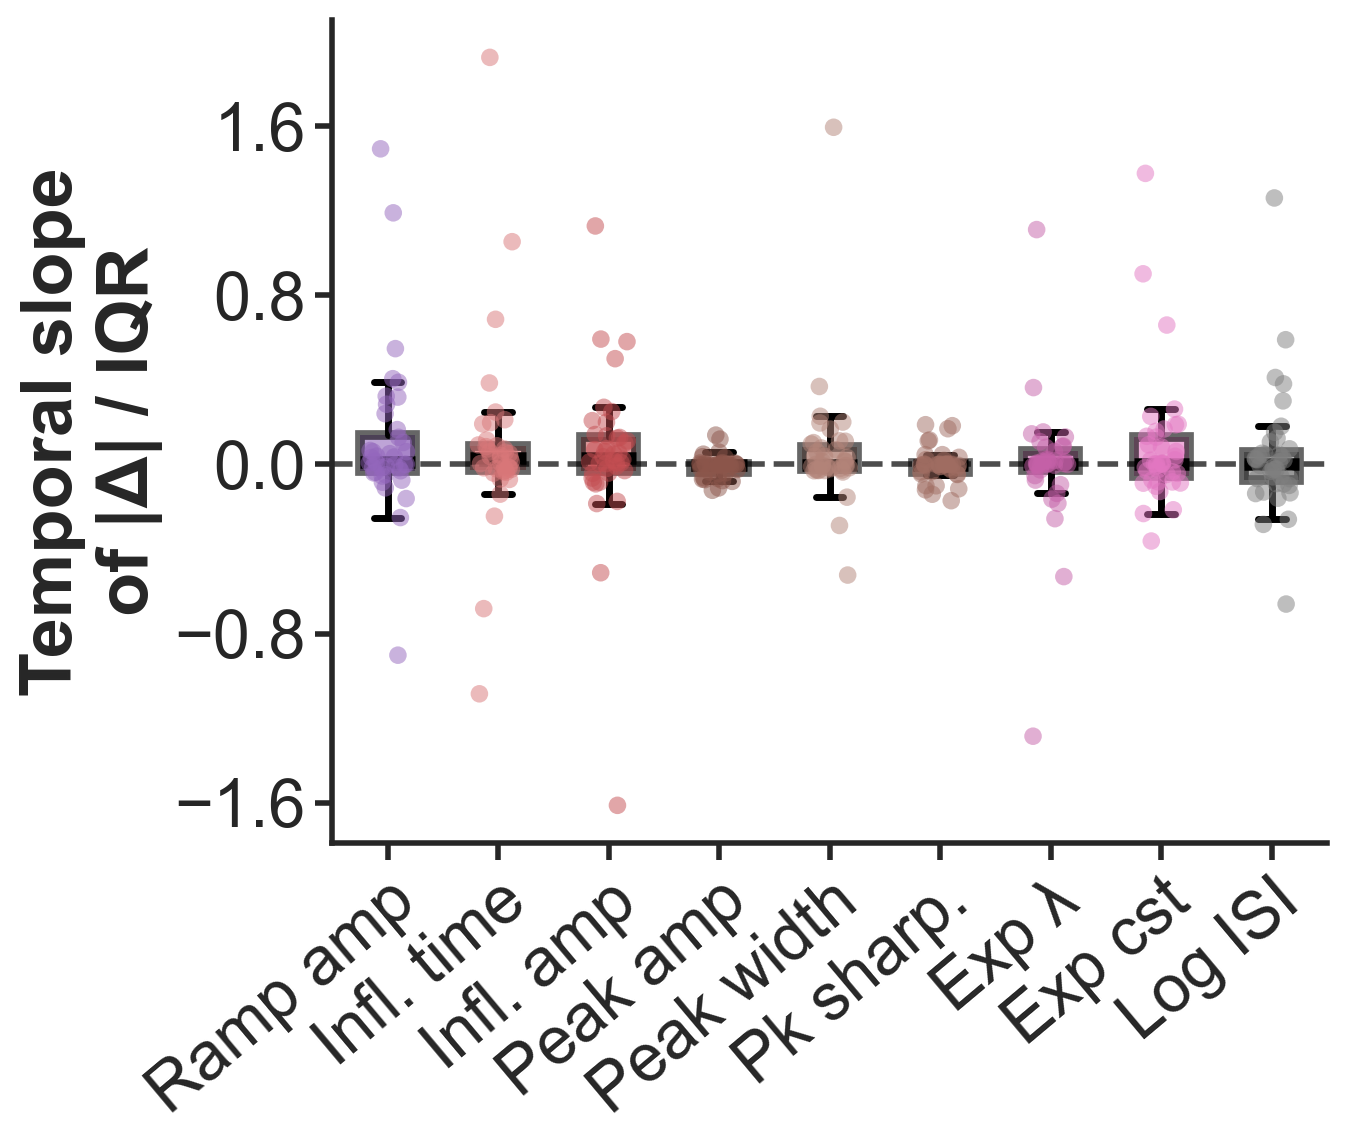


Feature                  n     median   p (slope>0)
----------------------------------------------------
Ramp amp                40     0.0120        0.0433
Infl. time              40     0.0307        0.0311
Infl. amp               40     0.0295        0.0241
Peak amp                40    -0.0026        0.9579
Peak width              40    -0.0020        0.0916
Peak sharp.             40    -0.0007        0.8159
Exp λ                   37     0.0042        0.2752
Exp const               40     0.0031        0.1841
Log ISI                 40     0.0041        0.4498
----------------------------------------------------
POOLED                 357     0.0008        0.0110


In [9]:
plot_temporal_slopes(CLUSTER_PKL_DIR)

## Panel D — Firing rate stability over time

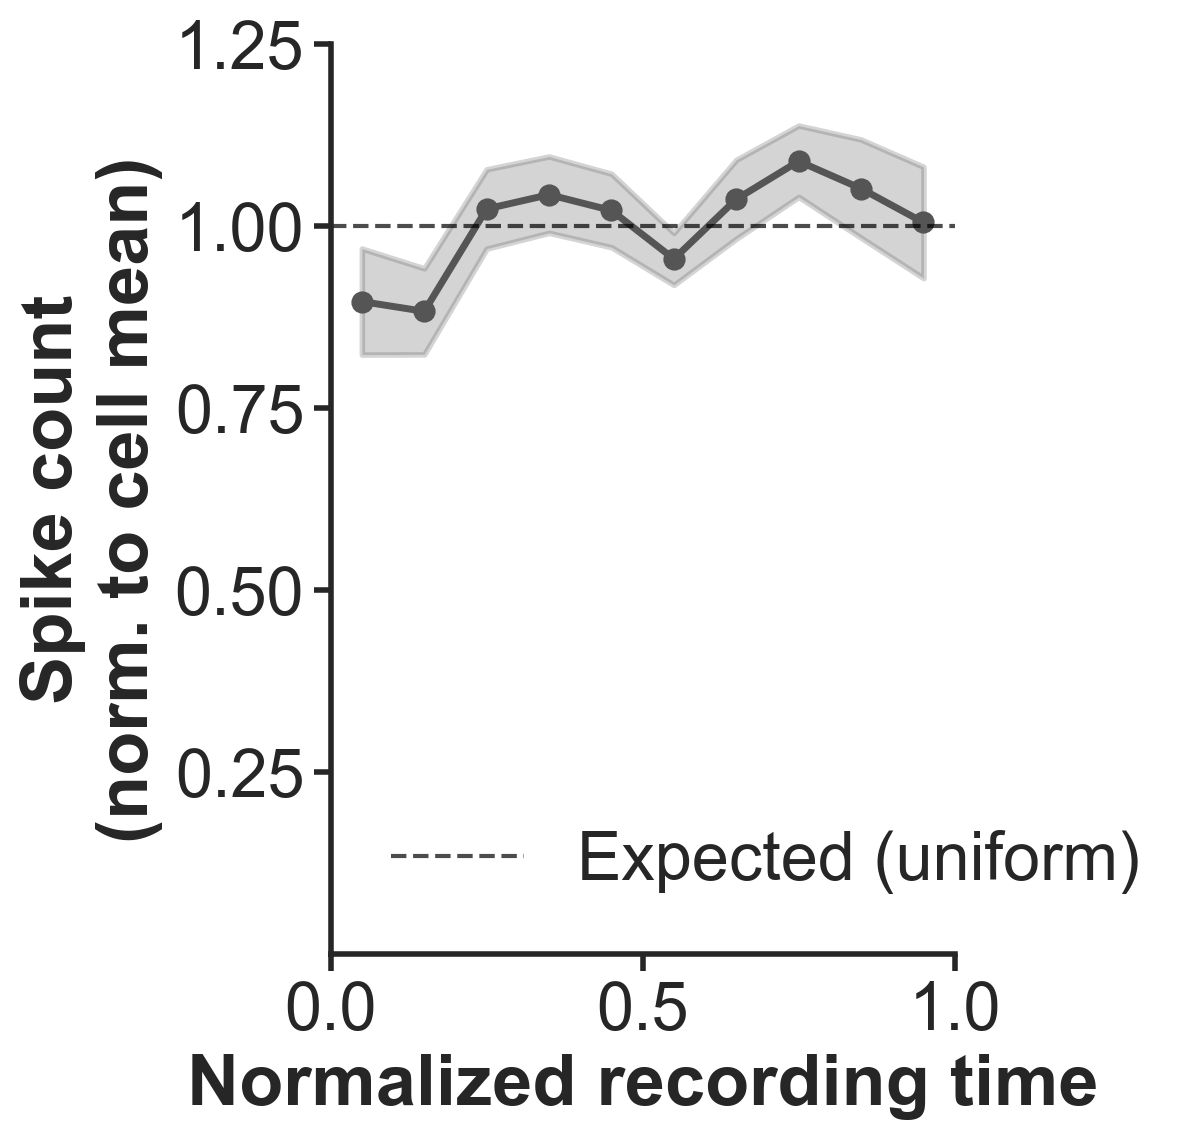

In [4]:
plot_firing_rate_stability(CLUSTER_PKL_DIR)

## Deep dive — c5/peak_width and c45/exp_lambda

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_4236/4013544435.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(unique_labs), 2))
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_4236/4013544435.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(unique_labs), 2))
/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_4236/4013544435.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or

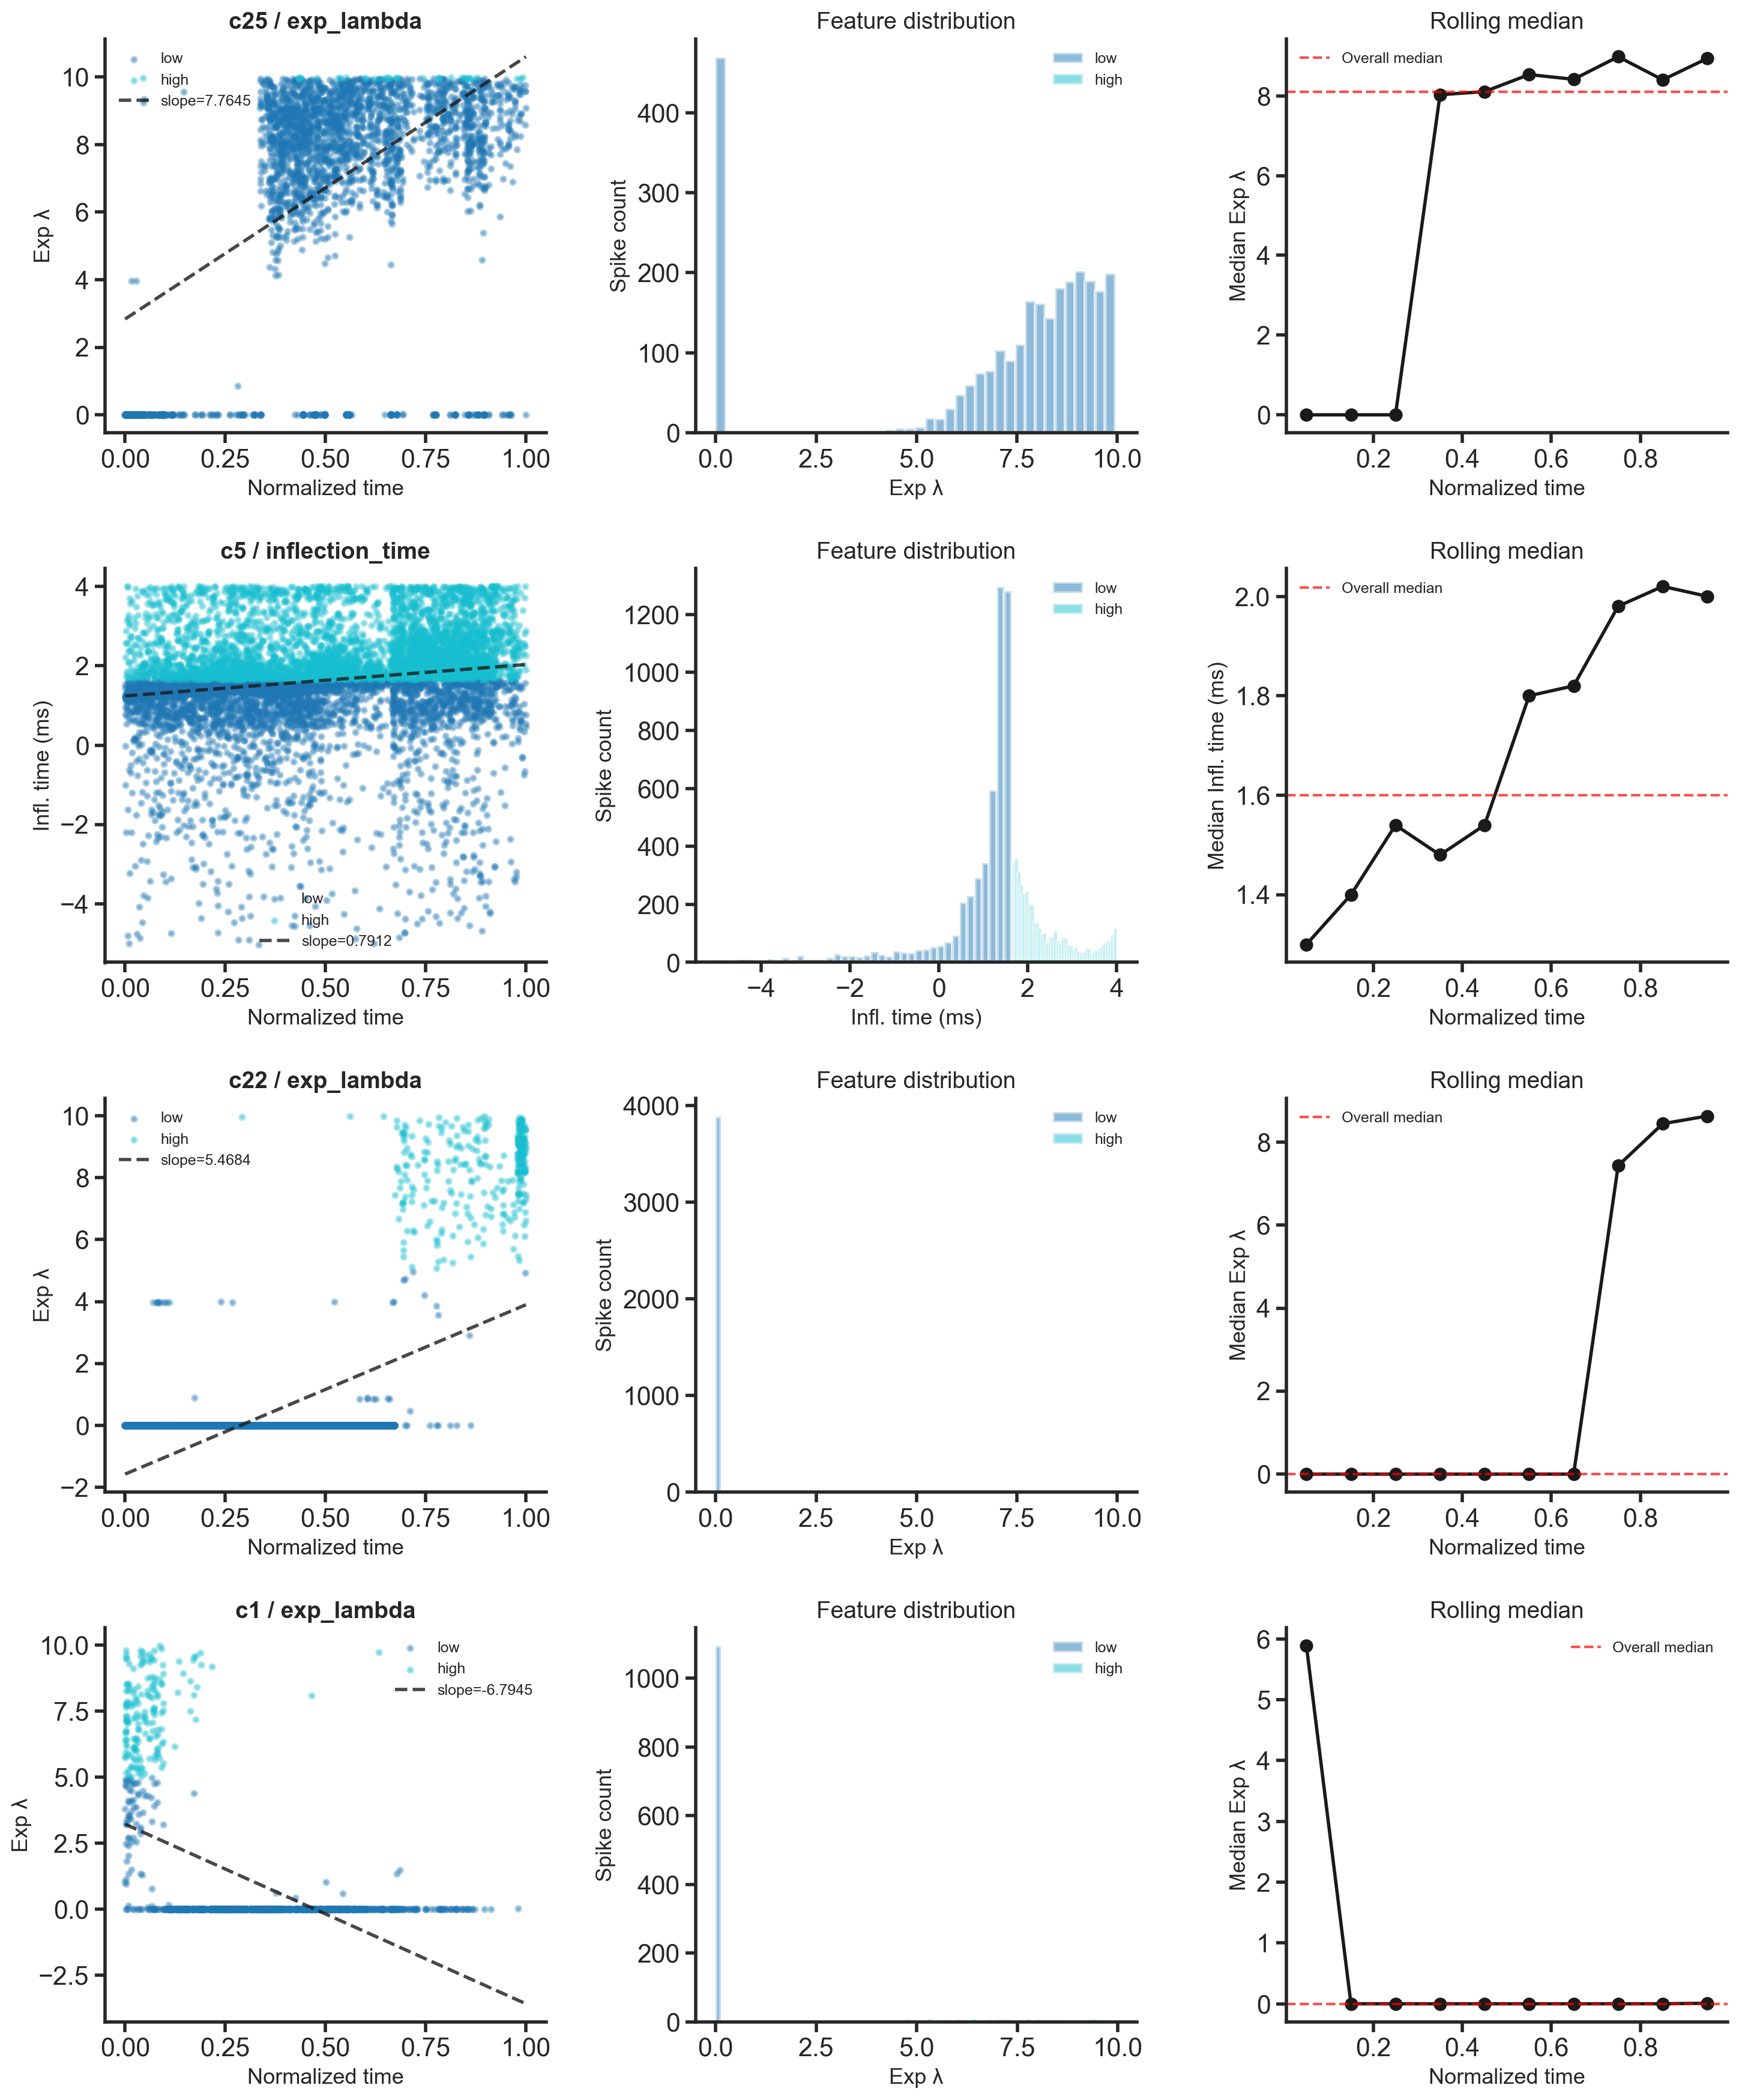

In [5]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
import sys, os
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikewise/Action potential waveforms are state-dependent paper/AP_empirical_paper_all_analyses/datasets/spe-1/spe1_helper_modules/')
import config
from scipy.stats import linregress
import seaborn as sns

CASES = [
    ('c25', 'exp_lambda',      'exp_lambda_cluster'),
    ('c5',  'inflection_time', 'inflection_time_cluster'),
    ('c22', 'exp_lambda',      'exp_lambda_cluster'),
    ('c1',  'exp_lambda',      'exp_lambda_cluster'),
]
PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'
FEAT_LABELS = {'peak_width': 'Peak width (ms)', 'exp_lambda': 'Exp λ', 'inflection_time': 'Infl. time (ms)'}

fig, axes = plt.subplots(len(CASES), 3, figsize=(15, 4.5 * len(CASES)))

for row, (cid, feat, clabel_col) in enumerate(CASES):
    pkl = os.path.join(PKL_DIR, f'{cid}_cluster_df.pkl')
    df  = pd.read_pickle(pkl)
    t   = df['spk_times_ms'].values.astype(float)
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-12)
    vals   = df[feat].values.astype(float)
    # apply validity bounds (same as analysis)
    if feat == 'peak_width':   vals[vals <= 0] = np.nan
    if feat == 'exp_lambda':   vals[(vals <= 0) | (vals >= 9.99)] = np.nan
    labels = df[clabel_col].values if clabel_col in df.columns else None

    unique_labs = list(dict.fromkeys(labels[pd.notna(labels)])) if labels is not None else []
    cmap = plt.cm.get_cmap('tab10', max(len(unique_labs), 2))
    lab_to_color = {lab: cmap(i) for i, lab in enumerate(unique_labs)}

    # --- scatter vs time ---
    ax0 = axes[row, 0]
    fin = np.isfinite(vals)
    for lab in unique_labs:
        mask = (labels == lab) & fin
        ax0.scatter(t_norm[mask], vals[mask], c=[lab_to_color[lab]], s=6, alpha=0.35, label=str(lab))
    slope, intercept, *_ = linregress(t_norm[fin], vals[fin])
    x_l = np.linspace(0, 1, 200)
    ax0.plot(x_l, slope*x_l + intercept, 'k--', lw=2, alpha=0.8, label=f'slope={slope:.4f}')
    ax0.set_xlabel('Normalized time', fontsize=13)
    ax0.set_ylabel(FEAT_LABELS.get(feat, feat), fontsize=13)
    ax0.set_title(f'{cid} / {feat}', fontsize=14, fontweight='bold')
    ax0.legend(fontsize=9, frameon=False)
    sns.despine(ax=ax0)

    # --- histogram by cluster ---
    ax1 = axes[row, 1]
    for lab in unique_labs:
        mask = (labels == lab) & fin
        ax1.hist(vals[mask], bins=40, color=lab_to_color[lab], alpha=0.5, label=str(lab))
    ax1.set_xlabel(FEAT_LABELS.get(feat, feat), fontsize=13)
    ax1.set_ylabel('Spike count', fontsize=13)
    ax1.set_title('Feature distribution', fontsize=14)
    ax1.legend(fontsize=9, frameon=False)
    sns.despine(ax=ax1)

    # --- rolling median vs time ---
    ax2 = axes[row, 2]
    bin_edges = np.linspace(0, 1, 11)
    bin_centers = 0.5*(bin_edges[:-1]+bin_edges[1:])
    medians = [np.nanmedian(vals[(t_norm >= lo) & (t_norm < hi)]) 
               for lo, hi in zip(bin_edges[:-1], bin_edges[1:])]
    ax2.plot(bin_centers, medians, 'ko-', lw=2, ms=7)
    ax2.axhline(np.nanmedian(vals[fin]), color='red', lw=1.5, ls='--', alpha=0.7, label='Overall median')
    ax2.set_xlabel('Normalized time', fontsize=13)
    ax2.set_ylabel(f'Median {FEAT_LABELS.get(feat, feat)}', fontsize=13)
    ax2.set_title('Rolling median', fontsize=14)
    ax2.legend(fontsize=9, frameon=False)
    sns.despine(ax=ax2)

plt.tight_layout(pad=1.5)
plt.show()
plt.close(fig)


---
## Figure caption (draft)

**Supplementary Figure X. AP waveform parameters are stable across recording time.**

**(A)** Scatter of feature values vs normalized recording time per spike (subsampled for display). Black dashed line: linear trend. No systematic drift is visible for any parameter.

**(B)** Rolling IQR of each waveform parameter across 10 equal-width time bins, summarized as mean ± SEM across cells. A flat profile indicates stable within-cell feature variability over the course of the recording.

**(C)** Distribution of temporal slopes: for each (cell × feature) pair, a linear regression of |spike value − cell mean| vs normalized recording time was fitted. A positive slope would indicate growing deviation from the cell's average waveform — consistent with electrode or patch degradation. Slopes are distributed symmetrically around zero and not significantly greater than zero (Wilcoxon signed-rank test, H1: slope > 0, printed above), indicating that waveform parameter variability does not systematically increase over the recording.